from experimentation, we found the best setup to be:

- Deduplicated dataset
- 50 SVD components
- k = 2

In [1]:
# This cell imports the libraries needed for clustering, evaluation, plotting, similarity search, and saving files.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [2]:
# This cell loads the updated SVD table from the balanced_desc_only dataset.
# This file already contains the SVD semantic vectors from the updated SVD notebook.

svd_df = pd.read_csv("../brit/balanced_desc_only_svd_table.csv")

print("SVD table shape:", svd_df.shape)
print("Columns:", svd_df.columns[:10].tolist(), "...")

svd_df.head()

SVD table shape: (10000, 1780)
Columns: ['name', 'description', 'average_score', 'class', 'SV_1', 'SV_2', 'SV_3', 'SV_4', 'SV_5', 'SV_6'] ...


,name,description,average_score,class,SV_1,SV_2,SV_3,SV_4,SV_5,SV_6,...,SV_1767,SV_1768,SV_1769,SV_1770,SV_1771,SV_1772,SV_1773,SV_1774,SV_1775,SV_1776
0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,1,0.313399,-0.241016,-0.208006,0.222448,-0.325501,-0.795861,...,-0.000006,0.000113,0.000067,0.000021,-0.000033,0.000089,0.000058,-0.000143,-0.000013,0.000201
1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,1,0.215025,-0.138837,-0.116791,-0.622929,0.656279,-0.313131,...,-0.000043,0.000014,0.000168,0.000098,-0.000091,-0.000068,-0.000015,0.000147,-0.000098,-0.000124
2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,1,0.313399,-0.241016,-0.208006,0.222448,-0.325501,-0.795861,...,-0.000006,0.000113,0.000067,0.000021,-0.000033,0.000089,0.000058,-0.000143,-0.000013,0.000201
3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,1,0.313399,-0.241016,-0.208006,0.222448,-0.325501,-0.795861,...,-0.000006,0.000113,0.000067,0.000021,-0.000033,0.000089,0.000058,-0.000143,-0.000013,0.000201
4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,1,0.215025,-0.138837,-0.116791,-0.622929,0.656279,-0.313131,...,-0.000043,0.000014,0.000168,0.000098,-0.000091,-0.000068,-0.000015,0.000147,-0.000098,-0.000124


In [3]:
# This cell selects all SVD feature columns.
# These are the numerical semantic vectors created from the game descriptions.
# We do not use name, description, average_score, or class as clustering inputs.

sv_cols = [col for col in svd_df.columns if col.startswith("SV_")]

X_svd = svd_df[sv_cols].values

print("Number of SVD columns:", len(sv_cols))
print("X_svd shape:", X_svd.shape)

Number of SVD columns: 1776
X_svd shape: (10000, 1776)


In [4]:
# This cell removes duplicate name-description pairs before clustering.
# This prevents repeated game entries from dominating the clustering result.

svd_unique_df = svd_df.drop_duplicates(subset=["name", "description"]).copy()

print("Original dataset shape:", svd_df.shape)
print("Deduplicated dataset shape:", svd_unique_df.shape)

Original dataset shape: (10000, 1780)
Deduplicated dataset shape: (4689, 1780)


In [5]:
# This cell keeps only the first 50 SVD components for clustering.
# Based on experimentation, 50 components gave the best clustering metrics.
# Using fewer components helps reduce noise from high-dimensional SVD features.

best_n_components = 50

final_sv_cols = [f"SV_{i}" for i in range(1, best_n_components + 1)]
final_sv_cols = [col for col in final_sv_cols if col in svd_unique_df.columns]

X_svd_unique_final = svd_unique_df[final_sv_cols].values

print("Number of final SVD components:", len(final_sv_cols))
print("Final clustering feature shape:", X_svd_unique_final.shape)

Number of final SVD components: 50
Final clustering feature shape: (4689, 50)


In [6]:
# This cell shows the experiment used to choose the number of SVD components.
# We test different component counts while keeping k=5.
# The best result came from using 50 SVD components.

component_results = []

component_options = [50, 100, 200, 300, 500, 750, 1000]

for n_components in component_options:
    selected_sv_cols = [f"SV_{i}" for i in range(1, n_components + 1)]
    selected_sv_cols = [col for col in selected_sv_cols if col in svd_unique_df.columns]

    X_temp = svd_unique_df[selected_sv_cols].values

    kmeans_temp = KMeans(
        n_clusters=5,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(X_temp)

    sil_temp = silhouette_score(X_temp, labels_temp)
    db_temp = davies_bouldin_score(X_temp, labels_temp)

    component_results.append({
        "n_components": len(selected_sv_cols),
        "k": 5,
        "silhouette_score": sil_temp,
        "davies_bouldin_score": db_temp
    })

component_results_df = pd.DataFrame(component_results)

component_results_df

,n_components,k,silhouette_score,davies_bouldin_score
0,50,5,0.140948,1.849512
1,100,5,0.084474,2.633972
2,200,5,0.045980,3.888346
3,300,5,0.035865,4.344357
4,500,5,0.024004,5.326427
5,750,5,0.016005,6.114369
6,1000,5,0.013021,6.801741


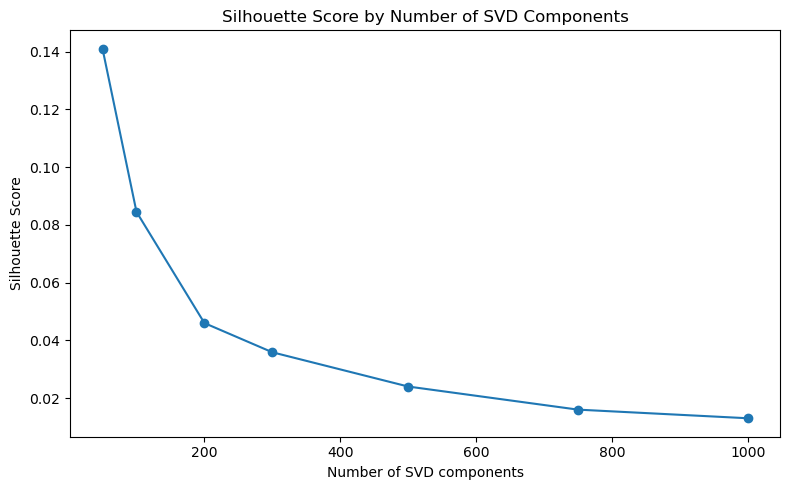

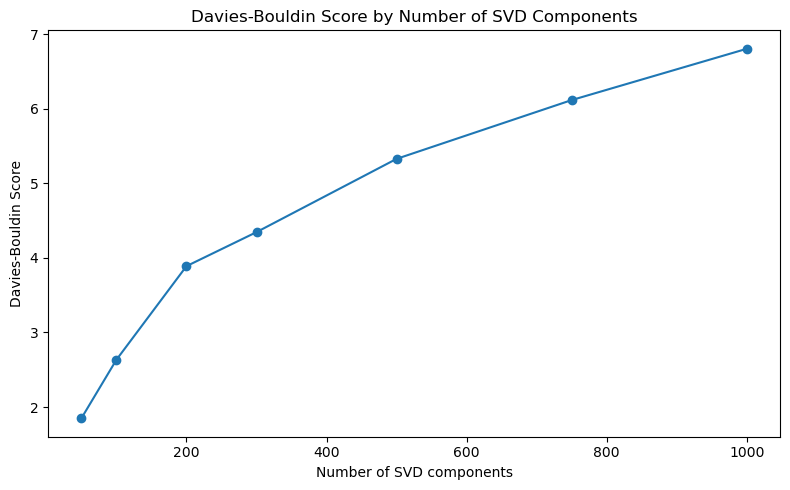

In [7]:
# This cell plots clustering scores for different SVD component counts.
# Higher silhouette score is better.
# Lower Davies-Bouldin score is better.

plt.figure(figsize=(8, 5))
plt.plot(component_results_df["n_components"], component_results_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of SVD Components")
plt.xlabel("Number of SVD components")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(component_results_df["n_components"], component_results_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score by Number of SVD Components")
plt.xlabel("Number of SVD components")
plt.ylabel("Davies-Bouldin Score")
plt.tight_layout()
plt.show()

In [8]:
# This cell tests different k values using the best SVD component count.
# Based on the previous experiment, 50 SVD components gave the best clustering scores.

k_results_50 = []

for k in range(2, 16):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(X_svd_unique_final)

    sil_temp = silhouette_score(X_svd_unique_final, labels_temp)
    db_temp = davies_bouldin_score(X_svd_unique_final, labels_temp)

    k_results_50.append({
        "k": k,
        "n_components": best_n_components,
        "silhouette_score": sil_temp,
        "davies_bouldin_score": db_temp
    })

k_results_50_df = pd.DataFrame(k_results_50)

k_results_50_df

,k,n_components,silhouette_score,davies_bouldin_score
0,2,50,0.226528,1.586351
1,3,50,0.114995,2.379672
2,4,50,0.137281,2.074265
3,5,50,0.140948,1.849512
4,6,50,0.113475,2.116754
5,7,50,0.112245,2.127181
6,8,50,0.089268,2.216943
7,9,50,0.093798,2.128070
8,10,50,0.097639,2.110035
9,11,50,0.089307,2.217501


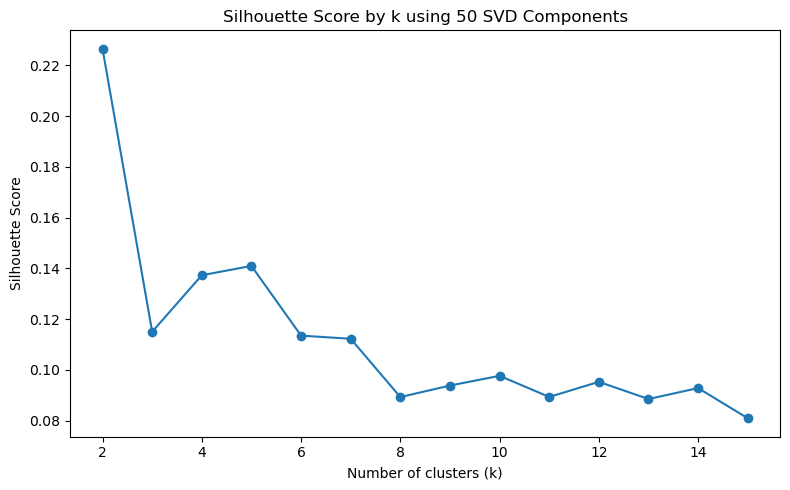

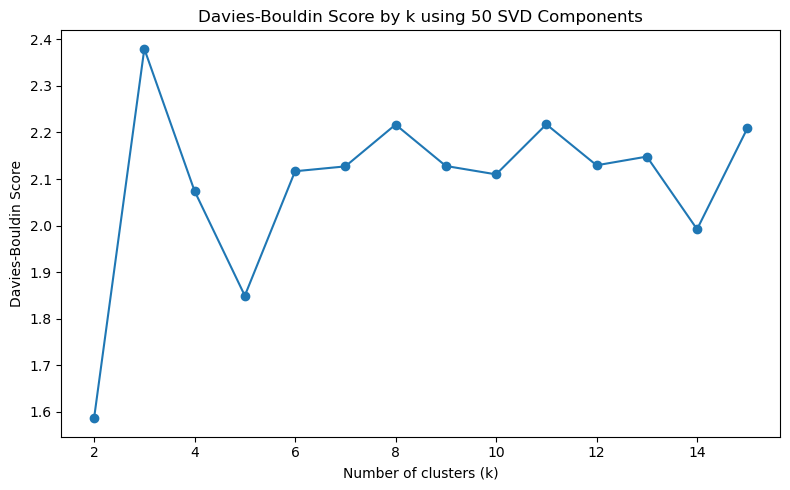

In [9]:
# This cell plots the k evaluation results using 50 SVD components.
# k=2 gave the best combination of highest silhouette score and lowest Davies-Bouldin score.

plt.figure(figsize=(8, 5))
plt.plot(k_results_50_df["k"], k_results_50_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by k using 50 SVD Components")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_results_50_df["k"], k_results_50_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score by k using 50 SVD Components")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Score")
plt.tight_layout()
plt.show()

In [10]:
# This cell runs the final KMeans clustering.
# Final setup:
# - deduplicated dataset
# - 50 SVD components
# - k=2 clusters

final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

svd_unique_df["kmeans_cluster"] = kmeans_final.fit_predict(X_svd_unique_final)

print("Final KMeans cluster counts:")
print(svd_unique_df["kmeans_cluster"].value_counts().sort_index())

Final KMeans cluster counts:
kmeans_cluster
0     707
1    3982
Name: count, dtype: int64


In [11]:
# This cell evaluates the final clustering result.
# These are the main final clustering metrics to report.

sil_final = silhouette_score(X_svd_unique_final, svd_unique_df["kmeans_cluster"])
db_final = davies_bouldin_score(X_svd_unique_final, svd_unique_df["kmeans_cluster"])

print(f"Final Silhouette Score: {sil_final:.4f}")
print(f"Final Davies-Bouldin Score: {db_final:.4f}")

Final Silhouette Score: 0.2265
Final Davies-Bouldin Score: 1.5864


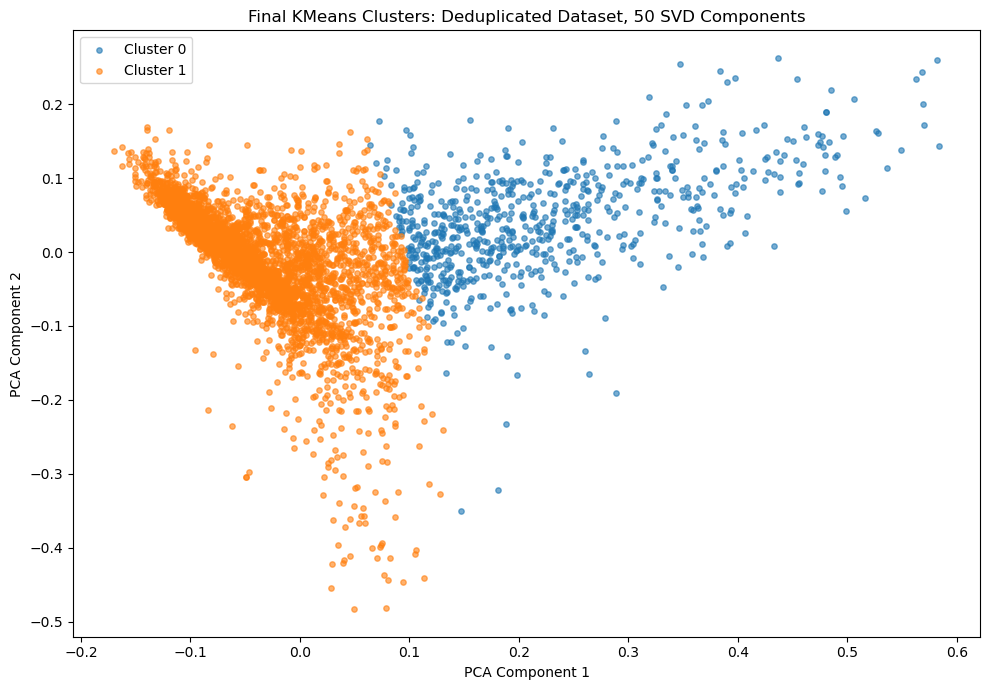

In [12]:
# This cell uses PCA only for visualization.
# PCA compresses the 50 SVD components into 2D so the clusters can be plotted.
# This does not change the actual KMeans clustering.

pca = PCA(n_components=2, random_state=42)
X_plot_final = pca.fit_transform(X_svd_unique_final)

svd_unique_df["plot_x"] = X_plot_final[:, 0]
svd_unique_df["plot_y"] = X_plot_final[:, 1]

plt.figure(figsize=(10, 7))

for cluster_id in sorted(svd_unique_df["kmeans_cluster"].unique()):
    cluster_data = svd_unique_df[svd_unique_df["kmeans_cluster"] == cluster_id]
    plt.scatter(
        cluster_data["plot_x"],
        cluster_data["plot_y"],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        s=15
    )

plt.title("Final KMeans Clusters: Deduplicated Dataset, 50 SVD Components")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# This cell summarizes each final KMeans cluster.
# It shows the number of games, score range, class distribution, and sample game titles.

def summarize_final_clusters(df, top_n=10):
    summaries = []

    for cluster_id in sorted(df["kmeans_cluster"].unique()):
        cluster_df = df[df["kmeans_cluster"] == cluster_id].copy()

        class_counts = cluster_df["class"].value_counts().sort_index().to_dict()
        sample_games = cluster_df["name"].head(top_n).tolist()

        summaries.append({
            "kmeans_cluster": cluster_id,
            "count": len(cluster_df),
            "average_score_mean": cluster_df["average_score"].mean(),
            "average_score_min": cluster_df["average_score"].min(),
            "average_score_max": cluster_df["average_score"].max(),
            "class_distribution": class_counts,
            "sample_games": sample_games
        })

    return pd.DataFrame(summaries)

final_cluster_summary = summarize_final_clusters(svd_unique_df)

final_cluster_summary

,kmeans_cluster,count,average_score_mean,average_score_min,average_score_max,class_distribution,sample_games
0,0,707,6.019318,2.25,10.0,"{2: 2, 3: 12, 4: 75, 5: 175, 6: 204, 7: 153, 8...","[Evil Dead 2: The Official Board Game, The Umb..."
1,1,3982,6.616634,1.00,10.0,"{1: 17, 2: 29, 3: 72, 4: 353, 5: 603, 6: 724, ...","[Rock Paper Scissors Game, Oneupmanship: Mine'..."


In [14]:
# This cell adds temporary names to the final KMeans clusters.
# Rename these after checking the cluster summaries.

cluster_names = {
    0: "Cluster 0",
    1: "Cluster 1"
}

svd_unique_df["kmeans_cluster_name"] = svd_unique_df["kmeans_cluster"].map(cluster_names)

svd_unique_df[["name", "average_score", "class", "kmeans_cluster", "kmeans_cluster_name"]].head()

,name,average_score,class,kmeans_cluster,kmeans_cluster_name
0,Rock Paper Scissors Game,1.31,1,1,Cluster 1
1,Oneupmanship: Mine's Bigger,1.04,1,1,Cluster 1
7,BreaKey,1.48,1,1,Cluster 1
500,Evil Dead 2: The Official Board Game,2.25,2,0,Cluster 0
502,Intelligent Design vs. Evolution,1.81,2,1,Cluster 1


In [15]:
# This cell runs hierarchical clustering inside each final KMeans cluster.
# KMeans gives broad groups, while hierarchical clustering gives smaller subgroups inside each broad group.

svd_unique_df["hierarchical_subcluster"] = -1

n_subclusters = 3

for cluster_id in sorted(svd_unique_df["kmeans_cluster"].unique()):
    cluster_indices = svd_unique_df[svd_unique_df["kmeans_cluster"] == cluster_id].index
    X_cluster = svd_unique_df.loc[cluster_indices, final_sv_cols].values

    if len(cluster_indices) < n_subclusters:
        svd_unique_df.loc[cluster_indices, "hierarchical_subcluster"] = 0
        continue

    hierarchical = AgglomerativeClustering(
        n_clusters=n_subclusters,
        linkage="ward"
    )

    subcluster_labels = hierarchical.fit_predict(X_cluster)

    svd_unique_df.loc[cluster_indices, "hierarchical_subcluster"] = subcluster_labels

svd_unique_df["full_cluster_label"] = (
    svd_unique_df["kmeans_cluster"].astype(str)
    + "-"
    + svd_unique_df["hierarchical_subcluster"].astype(str)
)

svd_unique_df[["name", "kmeans_cluster", "hierarchical_subcluster", "full_cluster_label"]].head()

,name,kmeans_cluster,hierarchical_subcluster,full_cluster_label
0,Rock Paper Scissors Game,1,0,1-0
1,Oneupmanship: Mine's Bigger,1,0,1-0
7,BreaKey,1,0,1-0
500,Evil Dead 2: The Official Board Game,0,0,0-0
502,Intelligent Design vs. Evolution,1,0,1-0


In [16]:
# This cell summarizes each hierarchical subcluster.
# It gives the count, score range, class distribution, and sample games for each smaller subgroup.

def summarize_final_subclusters(df, top_n=10):
    summaries = []

    for label in sorted(df["full_cluster_label"].unique()):
        subcluster_df = df[df["full_cluster_label"] == label].copy()

        class_counts = subcluster_df["class"].value_counts().sort_index().to_dict()
        sample_games = subcluster_df["name"].head(top_n).tolist()

        summaries.append({
            "full_cluster_label": label,
            "count": len(subcluster_df),
            "average_score_mean": subcluster_df["average_score"].mean(),
            "average_score_min": subcluster_df["average_score"].min(),
            "average_score_max": subcluster_df["average_score"].max(),
            "class_distribution": class_counts,
            "sample_games": sample_games
        })

    return pd.DataFrame(summaries)

final_subcluster_summary = summarize_final_subclusters(svd_unique_df)

final_subcluster_summary

,full_cluster_label,count,average_score_mean,average_score_min,average_score_max,class_distribution,sample_games
0,0-0,506,6.128700,2.25000,10.00,"{2: 1, 3: 8, 4: 51, 5: 110, 6: 144, 7: 116, 8:...","[Evil Dead 2: The Official Board Game, The Umb..."
1,0-1,137,5.794842,3.41000,9.43,"{3: 1, 4: 19, 5: 45, 6: 39, 7: 25, 8: 5, 9: 3}","[YOOLOO, Stun, Tetris: The Card Game, Go Fish,..."
2,0-2,64,5.635039,2.30000,7.66,"{2: 1, 3: 3, 4: 5, 5: 20, 6: 21, 7: 12, 8: 2}","[Non-Violent, Politically-Correct War, Snap, F..."
3,1-0,1601,6.088821,1.00000,10.00,"{1: 5, 2: 6, 3: 24, 4: 192, 5: 357, 6: 399, 7:...","[Rock Paper Scissors Game, Oneupmanship: Mine'..."
4,1-1,1850,6.935325,1.00000,10.00,"{1: 12, 2: 21, 3: 39, 4: 147, 5: 210, 6: 250, ...","[Onimaru, The Pumpkin King, Escape from the Gr..."
5,1-2,531,7.097708,1.71429,10.00,"{2: 2, 3: 9, 4: 14, 5: 36, 6: 75, 7: 150, 8: 1...","[War, Cootie, Chutes and Ladders, The Lord of ..."


In [17]:
# This cell finds the highest-scoring games in each final KMeans cluster.
# These can be used as top examples or competitive benchmarks.

top_games_per_final_cluster = (
    svd_unique_df
    .sort_values(["kmeans_cluster", "average_score"], ascending=[True, False])
    .groupby("kmeans_cluster")
    .head(10)
)

top_games_per_final_cluster[[
    "kmeans_cluster",
    "name",
    "average_score",
    "class"
]]

,kmeans_cluster,name,average_score,class
9646,0,The ‘King in Yellow' Tarot Deck,10.00000,10
9780,0,Ganghedge Manifesto,10.00000,10
4011,0,TerroriXico,9.43000,9
9291,0,Tarot d'Ambre,9.16667,9
4015,0,Composition,9.11000,9
4229,0,Animator vs Animation,9.06000,9
4033,0,Drinks & Daggers,9.04000,9
4086,0,Feuding Foodies,9.00000,9
4142,0,Sheep in Disguise,8.86000,9
4491,0,Sentinels of the Multiverse: Definitive Edition,8.83000,9


In [18]:
# This cell finds representative games for each final KMeans cluster.
# Representative games are closest to the cluster center, so they are the most typical examples.

representative_final_games = []

for cluster_id in sorted(svd_unique_df["kmeans_cluster"].unique()):
    cluster_indices = svd_unique_df[svd_unique_df["kmeans_cluster"] == cluster_id].index
    X_cluster = svd_unique_df.loc[cluster_indices, final_sv_cols].values

    centroid = kmeans_final.cluster_centers_[cluster_id].reshape(1, -1)

    similarities = cosine_similarity(X_cluster, centroid).flatten()

    best_local_positions = np.argsort(similarities)[::-1][:10]
    best_global_indices = cluster_indices[best_local_positions]

    temp = svd_unique_df.loc[best_global_indices, [
        "name",
        "average_score",
        "class",
        "kmeans_cluster",
        "kmeans_cluster_name"
    ]].copy()

    temp["similarity_to_centroid"] = similarities[best_local_positions]

    representative_final_games.append(temp)

representative_final_games_df = pd.concat(representative_final_games, ignore_index=True)

representative_final_games_df

,name,average_score,class,kmeans_cluster,kmeans_cluster_name,similarity_to_centroid
0,Jungle Speed: Rabbids,6.50000,6,0,Cluster 0,0.978969
1,Ice Cream,5.48000,5,0,Cluster 0,0.975475
2,Tute,6.81000,7,0,Cluster 0,0.974418
3,For the King (and Me),7.38000,7,0,Cluster 0,0.973927
4,Tales & Games: The Grasshopper & the Ant,6.24000,6,0,Cluster 0,0.973621
5,Arkham Ritual,5.37000,5,0,Cluster 0,0.971287
6,Défis Nature,5.10000,5,0,Cluster 0,0.971163
7,Chronos Conquest,6.00000,6,0,Cluster 0,0.970315
8,Minderheiten-Quartett,5.23000,5,0,Cluster 0,0.970106
9,Kingdom of Aer: Kingmaker,6.57000,7,0,Cluster 0,0.969820


In [19]:
# This cell defines a function that finds games similar to an existing game in the deduplicated dataset.
# It uses cosine similarity between the selected game's 50-component SVD vector and all other SVD vectors.

def find_similar_existing_game_final(game_name, top_n=10):
    matches = svd_unique_df[
        svd_unique_df["name"].str.contains(game_name, case=False, na=False)
    ]

    if matches.empty:
        print("No matching game found.")
        return None

    game_index = matches.index[0]
    game_vector = svd_unique_df.loc[[game_index], final_sv_cols].values

    similarities = cosine_similarity(game_vector, X_svd_unique_final).flatten()

    selected_position = svd_unique_df.index.get_loc(game_index)

    # Exclude the selected row itself
    similarities[selected_position] = -1

    top_positions = np.argsort(similarities)[::-1][:top_n]
    top_indices = svd_unique_df.index[top_positions]

    similar_games = svd_unique_df.loc[top_indices, [
        "name",
        "average_score",
        "class",
        "kmeans_cluster",
        "hierarchical_subcluster",
        "full_cluster_label"
    ]].copy()

    similar_games["similarity"] = similarities[top_positions]

    print("Selected game:")
    display(svd_unique_df.loc[[game_index], [
        "name",
        "average_score",
        "class",
        "kmeans_cluster",
        "hierarchical_subcluster",
        "full_cluster_label"
    ]])

    return similar_games

In [20]:
# This cell tests the similar-game function using an existing game title.
# You can replace the game title with another title from the dataset.

find_similar_existing_game_final("Rock Paper Scissors", top_n=10)

Selected game:


,name,average_score,class,kmeans_cluster,hierarchical_subcluster,full_cluster_label
0,Rock Paper Scissors Game,1.31,1,1,0,1-0


,name,average_score,class,kmeans_cluster,hierarchical_subcluster,full_cluster_label,similarity
1555,Rock Paper Scissors Lizard Spock Dice,4.40,4,1,0,1-0,0.750133
7678,Pac-Man: The Board Game,6.20,6,1,0,1-0,0.644889
1504,Pick Up Sticks,4.29,4,1,0,1-0,0.560645
2644,CribbGolf,6.17,6,1,0,1-0,0.556440
2382,Quip It!,4.94,5,1,0,1-0,0.544958
2032,ToeShamBo,5.14,5,0,1,0-1,0.522917
9405,The Enchanted Wood: DragonQuest Adventure Three,8.60,9,1,1,1-1,0.502633
7513,Triple Yahtzee,5.86,6,1,0,1-0,0.478283
4117,Gladiatoris,9.23,9,1,2,1-2,0.473850
1733,The Sudoku Game,4.32,4,1,0,1-0,0.468965


# This cell saves the final clustering results and summary tables as CSV files.

svd_unique_df.to_csv("final_deduplicated_svd_with_clusters.csv", index=False)
final_cluster_summary.to_csv("final_kmeans_cluster_summary.csv", index=False)
final_subcluster_summary.to_csv("final_hierarchical_subcluster_summary.csv", index=False)
representative_final_games_df.to_csv("final_representative_games_per_cluster.csv", index=False)
top_games_per_final_cluster.to_csv("final_top_games_per_cluster.csv", index=False)
component_results_df.to_csv("svd_component_experiment_results.csv", index=False)
k_results_50_df.to_csv("k_experiment_50_components_results.csv", index=False)

print("Saved final clustering output files.")

# This cell checks the file sizes of the clustering output files.
# Do not push any CSV that is over GitHub's normal file size limit.

output_files = [
    "final_deduplicated_svd_with_clusters.csv",
    "final_kmeans_cluster_summary.csv",
    "final_hierarchical_subcluster_summary.csv",
    "final_representative_games_per_cluster.csv",
    "final_top_games_per_cluster.csv",
    "svd_component_experiment_results.csv",
    "k_experiment_50_components_results.csv"
]

for file_name in output_files:
    if os.path.exists(file_name):
        size_mb = os.path.getsize(file_name) / (1024 * 1024)
        print(f"{file_name}: {size_mb:.2f} MB")
    else:
        print(f"{file_name} not found.")

## Final Clustering Result

The clustering experiment was revised because the full dataset contained many repeated game descriptions, which caused KMeans to isolate duplicate-heavy groups instead of producing useful clusters. To address this, duplicate `name` and `description` pairs were removed before clustering. This reduced the dataset from 10,000 rows to 4,689 unique game descriptions.

Several experiments were then performed. First, different SVD component counts were tested, including 50, 100, 200, 300, 500, 750, and 1000 components. The best result came from using 50 SVD components, which improved the clustering metrics compared to using all retained SVD features. Then, different values of `k` were tested using the 50-component representation.

The best final setup used the deduplicated dataset, 50 SVD components, and `k = 2`. This produced the highest silhouette score and lowest Davies-Bouldin score among the tested settings. The final clustering should be interpreted as an exploratory grouping rather than a perfect market segmentation, but it is more defensible than the original full-dataset clustering because it reduces duplicate effects and noisy high-dimensional features.